# LandArchetypes: Demo Workflow
**Study area:** Thrace, Greece  
**Stage:** 1. Land Archetype classification (mandatory)  

This notebook demonstrates the end-to-end workflow:
1. Clip input rasters to the study area boundary
2. Create coastline and river proximity buffer rasters
3. Align all rasters to a common grid (EPSG:3035, 100 m)
4. Classify the landscape into 15 land archetype classes
5. Visualise the archetype map
6. Profile the study area (hazard layers, community systems, area statistics)

> **Run this notebook from the project root directory** so that relative paths resolve correctly.

In [ ]:
import json
from pathlib import Path
from importlib.resources import files

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import rioxarray as rxr

from land_archetypes import (
    ArchetypeClassification,
    ArchetypeProfiler,
    GeospatialProcessingUtilities,
)
from land_archetypes.input_layers_mapping.mapping_tools import (
    build_eunis_code_map,
    build_clc_code_map,
)

In [2]:
# All paths are relative to the project root.
BASE_DIR   = Path(".").resolve()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent
INPUT_DIR  = BASE_DIR / "input_data"
OUTPUT_DIR = BASE_DIR / "output_data"
OUTPUT_DIR.mkdir(exist_ok=True)

# --- Input rasters ---
CLC_PATH   = INPUT_DIR / "corine"                   / "U2018_CLC2018_V2020_20u1.tif"
EUNIS_PATH = INPUT_DIR / "eunis"                    / "eea_r_3035_100_m_etm-full_2012_v3-1_r00.tif"
IMP_PATH   = INPUT_DIR / "copernicus_imperviousness" / "copernicus_imperviousness.tif"
DEM_PATH   = INPUT_DIR / "dem.tif"
POP_PATH   = INPUT_DIR / "grc_T_T_2021_CN_100m_R2025A_v1.tif"

# --- Input vectors ---
LINES_GPKG        = INPUT_DIR / "coastline_and_rivers.gpkg"
STUDY_AREA_GPKG   = INPUT_DIR / "remth.gpkg"
STUDY_AREA_LAYER  = "thrace_fixed_coastlines"

# --- Clipped raster output names (relative to OUTPUT_DIR) ---
CLC_CLIP   = OUTPUT_DIR / "clc_clipped.tif"
EUNIS_CLIP = OUTPUT_DIR / "eunis_clipped.tif"
IMP_CLIP   = OUTPUT_DIR / "imperviousness_clipped.tif"
DEM_CLIP   = OUTPUT_DIR / "dem_clipped.tif"
POP_CLIP   = OUTPUT_DIR / "pop_density_clipped.tif"
COAST_BUF  = OUTPUT_DIR / "coast_buffer.tif"
RIVER_BUF  = OUTPUT_DIR / "river_buffer.tif"

# --- Buffer distances (metres) ---
COAST_BUFFER_DIST = 1500   # adjust as needed
RIVER_BUFFER_DIST = 300   # adjust as needed

print(f"Project root : {BASE_DIR}")
print(f"Output folder: {OUTPUT_DIR}")
PRECEDENCE = None  # set in Step 4b to override; None uses the library default


Project root : C:\Users\xylop\Documents\github_repos\archetype_mapper_testing
Output folder: C:\Users\xylop\Documents\github_repos\archetype_mapper_testing\output_data


In [3]:
geo = GeospatialProcessingUtilities(
    output_path=str(OUTPUT_DIR),
    study_area_path=str(STUDY_AREA_GPKG),
    study_area_layer=STUDY_AREA_LAYER,
)

rasters_to_clip = {
    "clc_clipped.tif":              str(CLC_PATH),
    "eunis_clipped.tif":            str(EUNIS_PATH),
    "imperviousness_clipped.tif":   str(IMP_PATH),
    "dem_clipped.tif":              str(DEM_PATH),
    "pop_density_clipped.tif":      str(POP_PATH),
}

---
## Step 1. Clip input rasters to the study area

In [ ]:
for output_name, raster_path in rasters_to_clip.items():
    print(f"  Clipping {Path(raster_path).name} ...")
    geo.clip_raster_by_vector(output_name, raster_path)

print("\nAll rasters clipped.")

---
## Step 2. Create coastline and river buffer rasters

The clipped CLC raster is used as the spatial reference so the buffers are
produced on the same grid (EPSG:3035, 100 m).  
Buffer distances are set in the configuration cell above.

In [ ]:
print(f"Creating coastline buffer ({COAST_BUFFER_DIST} m) ...")
geo.create_line_buffer_raster(
    "coast_buffer.tif",
    line_path=str(LINES_GPKG),
    buffer_distance=COAST_BUFFER_DIST,
    line_layer="coastline",
    reference_raster_path=str(CLC_CLIP),
)

print(f"Creating river buffer ({RIVER_BUFFER_DIST} m) ...")
geo.create_line_buffer_raster(
    "river_buffer.tif",
    line_path=str(LINES_GPKG),
    buffer_distance=RIVER_BUFFER_DIST,
    line_layer="rivers",
    reference_raster_path=str(CLC_CLIP),
)

print("Applying delta mask: clearing river buffer at coast–river overlap ...")
geo.clear_buffer_overlap(
    output_name="river_buffer.tif",
    source_buffer_path=str(RIVER_BUF),
    mask_buffer_path=str(COAST_BUF),
)

print("Buffer rasters created.")

---
## Step 3. Load and align all rasters to a common grid

All rasters are reprojected to **EPSG:3035** at **100 m** resolution and
matched to the CLC grid using `reproject_match`.  
Categorical layers (CLC, EUNIS, buffers) use nearest-neighbour resampling;
continuous layers (DEM, imperviousness, population density) use bilinear.

In [4]:
print("Loading clipped rasters ...")

raw = {
    "clc":                rxr.open_rasterio(CLC_CLIP,   masked=True, chunks="auto"),
    "eunis":              rxr.open_rasterio(EUNIS_CLIP,  masked=True, chunks="auto"),
    "imperviousness":     rxr.open_rasterio(IMP_CLIP,   masked=True, chunks="auto"),
    "dem":                rxr.open_rasterio(DEM_CLIP,    masked=True, chunks="auto"),
    "population_density": rxr.open_rasterio(POP_CLIP,   masked=True, chunks="auto"),
    "coast_buffer":       rxr.open_rasterio(COAST_BUF,  masked=True, chunks="auto"),
    "river_buffer":       rxr.open_rasterio(RIVER_BUF,  masked=True, chunks="auto"),
}

print(f"{'Layer':<22} {'Shape':>16}  CRS")
print("-" * 60)
for name, da in raw.items():
    shape = str(tuple(da.squeeze().shape))
    print(f"{name:<22} {shape:>16}  {da.rio.crs}")

Loading clipped rasters ...
Layer                             Shape  CRS
------------------------------------------------------------
clc                        (1592, 2473)  EPSG:3035
eunis                      (1592, 2473)  EPSG:3035
imperviousness           (15908, 24722)  EPSG:3035
dem                        (5304, 8241)  EPSG:3035
population_density         (1988, 3089)  EPSG:3035
coast_buffer               (1592, 2473)  EPSG:3035
river_buffer               (1592, 2473)  EPSG:3035


In [5]:
print("Reprojecting and aligning to CLC grid (EPSG:3035, 100 m) ...")

ras = geo.reproject_rasters(
    raw,
    target_crs=3035,
    reference_key="clc",
    pixel_size=100,
    categorical_keys={"clc", "eunis", "coast_buffer", "river_buffer"},
)

print(f"\n{'Layer':<22} {'Shape':>16}  CRS")
print("-" * 60)
for name, da in ras.items():
    shape = str(tuple(da.squeeze().shape))
    print(f"{name:<22} {shape:>16}  {da.rio.crs}")

print("\nAll rasters aligned.")

Reprojecting and aligning to CLC grid (EPSG:3035, 100 m) ...

Layer                             Shape  CRS
------------------------------------------------------------
clc                        (1592, 2473)  EPSG:3035
eunis                      (1592, 2473)  EPSG:3035
imperviousness             (1592, 2473)  EPSG:3035
dem                        (1592, 2473)  EPSG:3035
population_density         (1592, 2473)  EPSG:3035
coast_buffer               (1592, 2473)  EPSG:3035
river_buffer               (1592, 2473)  EPSG:3035

All rasters aligned.


---
## Step 4. Build code maps and load archetype rules

In [6]:
# Load mapping tables from the installed package data
eunis_df = pd.read_csv(files("land_archetypes") / "input_layers_mapping" / "eunis_l2_mapping.csv")
clc_df   = pd.read_csv(files("land_archetypes") / "input_layers_mapping" / "clc_mapping.csv")

eunis_map = build_eunis_code_map(eunis_df)
clc_map   = build_clc_code_map(clc_df)

print(f"EUNIS code map : {len(eunis_map)} entries")
print(f"CLC code map   : {len(clc_map)} entries")

_rules_path = files("land_archetypes") / "archetype_classes" / "archetype_classes.json"
with _rules_path.open("r", encoding="utf-8") as f:
    rules = json.load(f)

print(f"Archetype rules: {len(rules)} archetypes")

EUNIS code map : 44 entries
CLC code map   : 45 entries
Archetype rules: 16 archetypes


---
## Step 4b. — Classification precedence *(optional)*

Override the default evaluation order defined in the library.
Skip this cell to use the library default.
**If you do run it, run it before Step 5.**

In [ ]:
# Override the default precedence if needed.
# The library default (archetype_classification.py) is used when PRECEDENCE is None:
#   ["A2","A3","A1","A4","B3","B2","B1","B4","B5","B6","D1","D2","C2","C3","C1","C4"]
#
# Edit and uncomment the block below to use a custom order:
# PRECEDENCE = [
#     "A2", "A3", "A1", "A4", "B3", "B2", "B1", "B4", "B5", "B6",
#     "D1", "D2", "C2", "C3", "C1", "C4",
# ]

if PRECEDENCE is None:
    print("Precedence: library default")
else:
    print("Precedence (custom):", PRECEDENCE)


---
## Step 5. Land Archetype classification

Classification follows a **first-match-wins** precedence order (most spatially
constrained archetype checked first).  
See `README.md` for the full precedence table and instructions on overriding
default rule thresholds.

In [7]:
clf = ArchetypeClassification()

archetype_raster = clf.derive_archetype_raster_map(
    output_path=str(OUTPUT_DIR),
    archetype_map_name="archetypes.tif",
    ras=ras,
    rules=rules,
    eunis_code_map=eunis_map,
    clc_code_map=clc_map,
    precedence=PRECEDENCE,
    rule_overrides={
        "C1": {"population_density_constraint": [0, 0]},
        "C3": {"population_density_constraint": [0, 0]},
    },
    # clc_fallback=True,
)

# Parse lookup (may be a string when re-read from disk)
_lkp = archetype_raster.attrs["class_id_lookup"]
if isinstance(_lkp, str):
    _lkp = json.loads(_lkp)
archetype_raster.attrs["class_id_lookup"] = _lkp

# Save lookup so Step 6+ can be run independently
with open(OUTPUT_DIR / "class_id_lookup.json", "w") as f:
    json.dump(_lkp, f)

print("Classification complete.")
print(f"Output : {OUTPUT_DIR / 'archetypes.tif'}")
print(f"Lookup : {OUTPUT_DIR / 'class_id_lookup.json'}")
print()
print("Class ID lookup:")
for code, id_ in sorted(_lkp.items(), key=lambda x: x[1]):
    print(f"  {id_:>2}  {code}  {rules[code]['name']}")

Classification complete.
Output : C:\Users\xylop\Documents\github_repos\archetype_mapper_testing\output_data\archetypes.tif
Lookup : C:\Users\xylop\Documents\github_repos\archetype_mapper_testing\output_data\class_id_lookup.json

Class ID lookup:
   1  A2  Beach-Dune System
   2  A3  Transitional Coastal Water System
   3  A1  Marine/Subtidal
   4  A4  Coastal Natural Plains & Forests
   5  B3  Coastal Urban
   6  B2  Riverine Urban
   7  B1  Inland Urban
   8  B4  Suburban
   9  B5  Mountainous Urban
  10  B6  Industrial / Commercial
  11  C2  Inland Waterbody Systems
  12  C3  Rural Settlements
  13  C1  Agricultural Land
  14  C4  Inland Natural Plains & Forests
  15  D1  Mountainous/Forested
  16  D2  High-Altitude Meadows & Scrub


c:\Users\xylop\.virtualenvs\tests-O8ozFrma\Lib\site-packages\land_archetypes\archetype_classification.py:90: FutureWarning: It is recommended to use 'rio.write_crs()' instead. 'rio.set_crs()' will likelybe removed in a future release.
  out = out.rio.set_crs("EPSG:3035")  # ensure CRS is set before saving


---
## Step 5b. — Diagnose unclassified pixels

`ArchetypeProfiler.diagnose_unclassified` walks every unclassified pixel,
finds the first archetype whose CLC codes match, and reports which constraint
blocks classification — together with a concrete suggestion for each issue.

In [ ]:
DIAG_DIR = OUTPUT_DIR / "diagnosis_data"

diag = ArchetypeProfiler.export_diagnosis_rasters(
    archetype_raster=archetype_raster,
    ras=ras,
    rules=rules,
    eunis_code_map=eunis_map,
    clc_code_map=clc_map,
    output_path=str(DIAG_DIR),
)
ArchetypeProfiler.print_diagnosis(diag, output_path=str(DIAG_DIR))

---
## Step 5c. — CLC fallback (optional)

If the diagnostic above shows a significant number of unclassified pixels
caused by CLC / EUNIS mismatches (e.g. agricultural CLC with forest EUNIS),
set `USE_CLC_FALLBACK = True` and re-run this cell.

A second classification pass will run **only on the remaining 255 pixels**,
ignoring the EUNIS constraint and relying on CLC and all other spatial
constraints. Two outputs are saved:

- `archetypes.tif` — first-pass result (CLC + EUNIS)
- `archetypes_clc_fallback.tif` — second-pass result (CLC only for 255 pixels)

Outside-study-area pixels (CLC = NaN) are never affected.

In [8]:
USE_CLC_FALLBACK = True  # set to True after reviewing the Step 5b diagnostics

if USE_CLC_FALLBACK:
    print("Running CLC fallback pass ...")
    archetype_raster = clf.derive_archetype_raster_map(
        output_path=str(OUTPUT_DIR),
        archetype_map_name="archetypes.tif",
        ras=ras,
        rules=rules,
        eunis_code_map=eunis_map,
        clc_code_map=clc_map,
        precedence=PRECEDENCE,
        rule_overrides={
            "C1": {"population_density_constraint": [0, 0]},
            "C3": {"population_density_constraint": [0, 0]},
        },
        clc_fallback=True,
    )
    _lkp = archetype_raster.attrs["class_id_lookup"]
    if isinstance(_lkp, str):
        _lkp = json.loads(_lkp)
    archetype_raster.attrs["class_id_lookup"] = _lkp
    with open(OUTPUT_DIR / "class_id_lookup.json", "w") as f:
        json.dump(_lkp, f)
    print(f"First pass  : {OUTPUT_DIR / 'archetypes.tif'}")
    print(f"CLC fallback: {OUTPUT_DIR / 'archetypes_clc_fallback.tif'}")
else:
    print("CLC fallback skipped. Set USE_CLC_FALLBACK = True to activate.")

Running CLC fallback pass ...
First pass  : C:\Users\xylop\Documents\github_repos\archetype_mapper_testing\output_data\archetypes.tif
CLC fallback: C:\Users\xylop\Documents\github_repos\archetype_mapper_testing\output_data\archetypes_clc_fallback.tif


In [9]:
first = rxr.open_rasterio(str(OUTPUT_DIR / "archetypes.tif"), masked=False).squeeze()
fb    = rxr.open_rasterio(str(OUTPUT_DIR / "archetypes_clc_fallback.tif"), masked=False).squeeze()
diff  = (first.values == 255) & (fb.values != 255)
print("First pass unclassified:", (first.values == 255).sum())
print("Fallback unclassified:  ", (fb.values == 255).sum())
print("Pixels classified by fallback:", diff.sum())



First pass unclassified: 2682728
Fallback unclassified:   2562423
Pixels classified by fallback: 120305


---
## Step 5d. Diagnose unclassified pixels (post-fallback)

Re-run the same diagnostic after the CLC fallback step to confirm how many
pixels remain unclassified and whether any new constraint failures have appeared.

In [ ]:
_fb_path = OUTPUT_DIR / "archetypes_clc_fallback.tif"
if _fb_path.exists():
    _diag2_raster = rxr.open_rasterio(_fb_path, masked=True).squeeze()
    with open(OUTPUT_DIR / "class_id_lookup.json") as _f:
        _diag2_raster.attrs["class_id_lookup"] = json.load(_f)
    _skip_eunis = True
else:
    _diag2_raster = archetype_raster
    _skip_eunis = False

DIAG_DIR2 = OUTPUT_DIR / "diagnosis_data_postfallback"

diag2 = ArchetypeProfiler.export_diagnosis_rasters(
    archetype_raster=_diag2_raster,
    ras=ras,
    rules=rules,
    eunis_code_map=eunis_map,
    clc_code_map=clc_map,
    output_path=str(DIAG_DIR2),
    skip_eunis=_skip_eunis,
)
ArchetypeProfiler.print_diagnosis(diag2, output_path=str(DIAG_DIR2))

---
## Step 6. Visualise the archetype map

QML  saved → archetypes.qml
QML  saved → archetypes_clc_fallback.qml


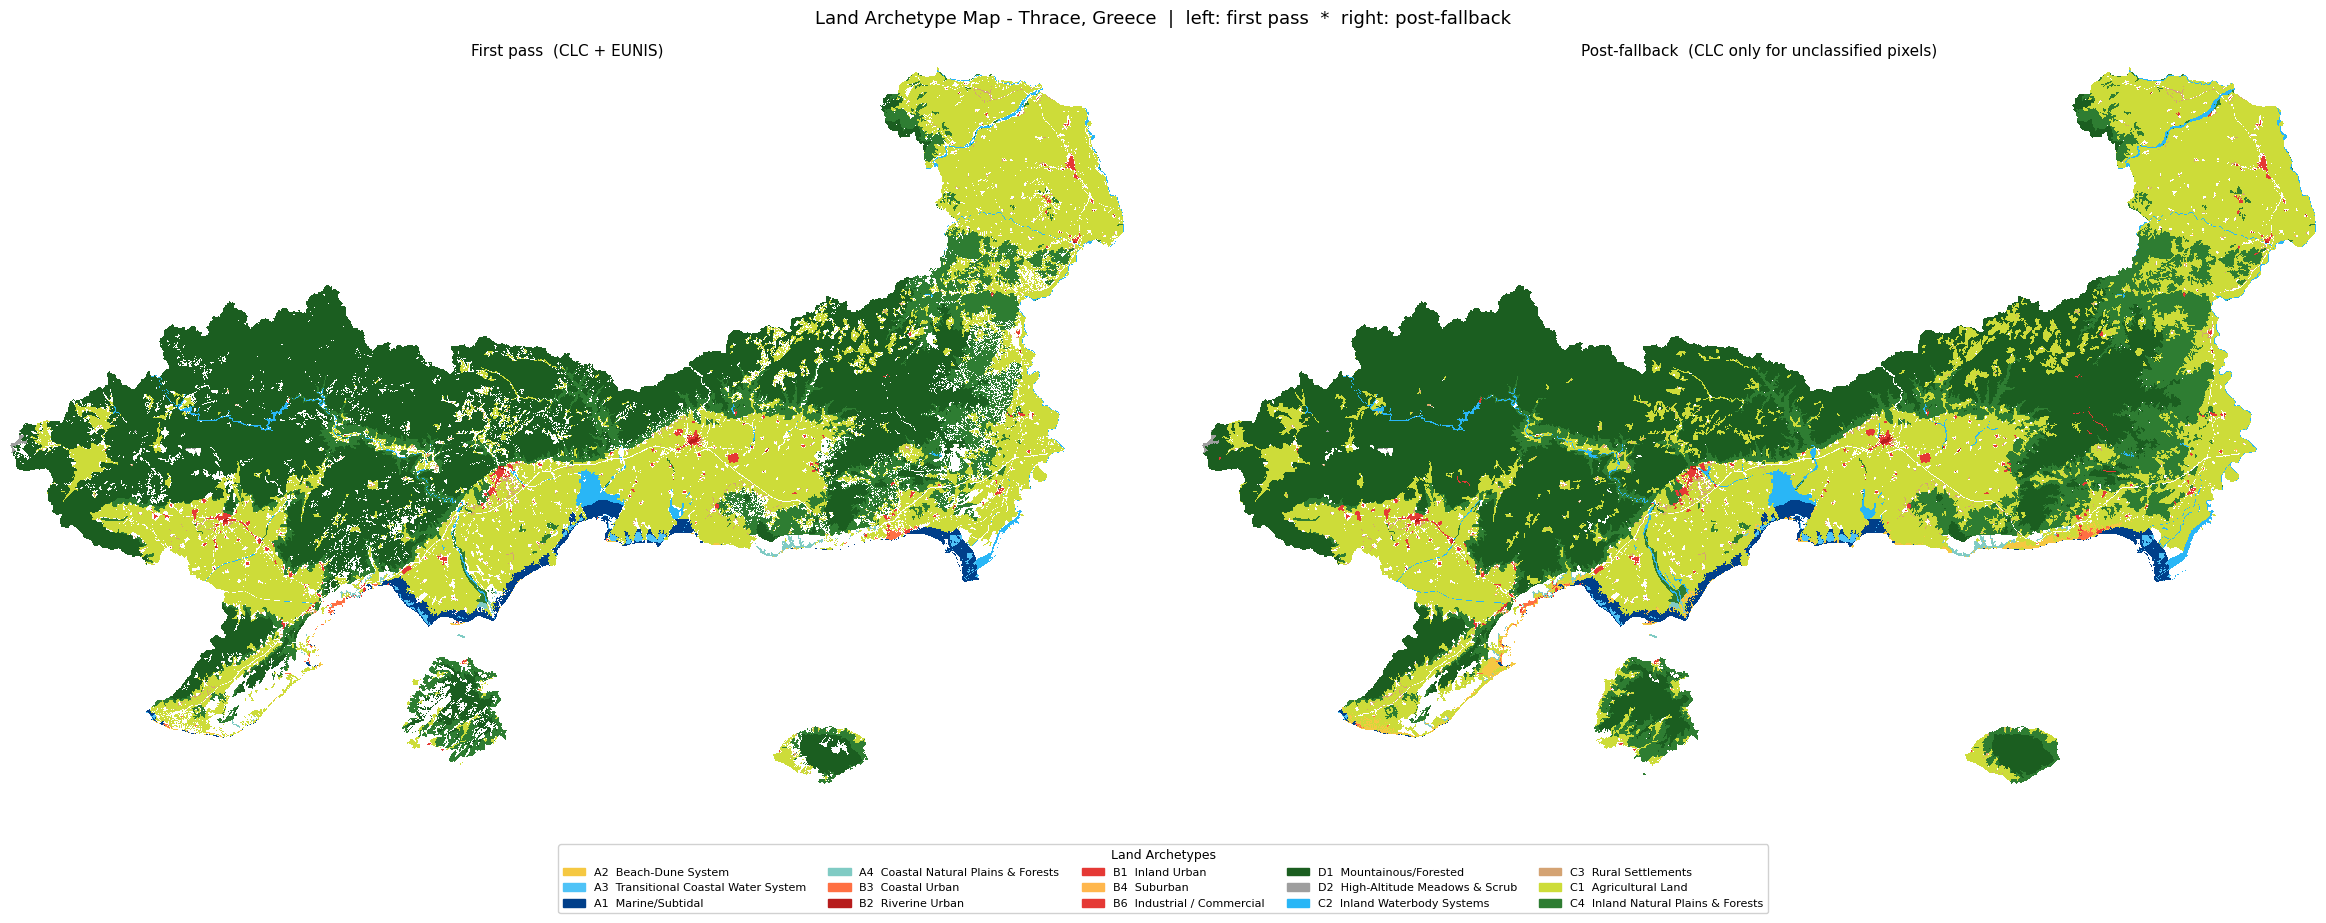

Map saved to C:\Users\xylop\Documents\github_repos\archetype_mapper_testing\output_data\archetype_map_combined.png


In [10]:
try:
    archetype_raster
except NameError:
    _tif = OUTPUT_DIR / "archetypes.tif"
    if not _tif.exists():
        raise FileNotFoundError(
            f"No archetype raster found at {_tif}. Run Steps 1-5 first."
        )
    archetype_raster = rxr.open_rasterio(_tif, masked=True).squeeze()
    with open(OUTPUT_DIR / "class_id_lookup.json") as f:
        archetype_raster.attrs["class_id_lookup"] = json.load(f)
    rules_path = files("land_archetypes") / "archetype_classes" / "archetype_classes.json"
    with rules_path.open("r", encoding="utf-8") as f:
        rules = json.load(f)
    print("Archetype raster loaded from disk.")

# --- Dynamic colour palette (group-aware, adapts to added/removed classes) ---
def _generate_archetype_colors(rules):
    _GROUP_PALETTES = {
        "Coastal":     ["#003f8a", "#f5c842", "#4fc3f7", "#80cbc4", "#a0d4c1"],
        "Urban":       ["#e53935", "#b71c1c", "#ff7043", "#ffb74d", "#795548"],
        "Rural":       ["#cddc39", "#29b6f6", "#d4a373", "#2e7d32", "#8bc34a"],
        "Mountainous": ["#1b5e20", "#9e9e9e", "#546e7a", "#37474f"],
    }
    _FALLBACK = [
        "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
        "#a65628", "#f781bf", "#17becf", "#bcbd22", "#e377c2",
    ]
    counters, out = {}, {}
    for key, rule in rules.items():
        grp = rule.get("archetype", "")
        pal = _GROUP_PALETTES.get(grp, _FALLBACK)
        idx = counters.get(grp, 0)
        out[key] = pal[idx % len(pal)]
        counters[grp] = idx + 1
    return out

ARCHETYPE_COLORS = _generate_archetype_colors(rules)

lookup = archetype_raster.attrs["class_id_lookup"]
if isinstance(lookup, str):
    lookup = json.loads(lookup)
id_to_key = {v: k for k, v in lookup.items()}
nodata    = int(archetype_raster.rio.nodata or 255)

# --- Write QGIS style files (.qml) for every archetype TIF ---
def _write_archetype_qml(tif_path, lookup, archetype_colors, rules):
    """Write a paletted .qml alongside tif_path using the current color map."""
    def _xe(s):
        return (s.replace("&", "&amp;").replace("<", "&lt;")
                 .replace(">", "&gt;").replace('"', "&quot;"))
    entries = []
    for key, class_id in sorted(lookup.items(), key=lambda x: x[1]):
        color = archetype_colors.get(key, "#cccccc")
        name  = rules.get(key, {}).get("name", key)
        entries.append(
            f'      <paletteEntry alpha="255" color="{color}" ' +
            f'value="{class_id}" label="{_xe(f"{key}  {name}")}"/>'
        )
    entries.append(
        '      <paletteEntry alpha="0" color="#000000" ' +
        'value="255" label="Unclassified / nodata"/>'
    )
    qml = (
        "<!DOCTYPE qgis PUBLIC 'http://mrcc.com/qgis.dtd' 'SYSTEM'>\n"
        '<qgis version="3.0" styleCategories="AllStyleCategories">\n'
        " <pipe>\n"
        '  <rasterrenderer alphaBand="-1" opacity="1" type="paletted" band="1" nodataColor="">\n'
        "   <rasterTransparency/>\n"
        "   <colorPalette>\n"
        + "\n".join(entries) + "\n"
        + "   </colorPalette>\n"
        "  </rasterrenderer>\n"
        '  <brightnesscontrast brightness="0" contrast="0" gamma="1"/>\n'
        '  <huesaturation colorizeBlue="128" colorizeGreen="128" colorizeOn="0"'
        ' colorizeRed="255" colorizeStrength="100" grayscaleMode="0" saturation="0"/>\n'
        '  <rasterresampler maxOversampling="2"/>\n'
        " </pipe>\n"
        " <blendMode>0</blendMode>\n"
        "</qgis>\n"
    )
    qml_path = Path(str(tif_path)).with_suffix(".qml")
    with open(qml_path, "w", encoding="utf-8") as fq:
        fq.write(qml)
    print(f"QML  saved → {qml_path.name}")


# --- Collect panels (first pass always; fallback when available) ---
_first_tif = OUTPUT_DIR / "archetypes.tif"
_fb_tif    = OUTPUT_DIR / "archetypes_clc_fallback.tif"
panels = [(_first_tif, "First pass  (CLC + EUNIS)")]
if _fb_tif.exists():
    panels.append((_fb_tif, "Post-fallback  (CLC only for unclassified pixels)"))

for tif_path, _ in panels:
    _write_archetype_qml(tif_path, lookup, ARCHETYPE_COLORS, rules)

# Load arrays and build a unified present-ID set for a shared legend
arrays, all_present_ids = [], set()
for tif_path, _ in panels:
    arr = rxr.open_rasterio(str(tif_path), masked=False).squeeze().values
    arrays.append(arr)
    all_present_ids.update(int(v) for v in arr.ravel() if int(v) != nodata)

present_ids  = sorted(all_present_ids)
present_keys = [id_to_key[i] for i in present_ids if i in id_to_key]
id_to_idx    = {aid: idx for idx, aid in enumerate(present_ids)}

colors = [ARCHETYPE_COLORS.get(k, "#cccccc") for k in present_keys]
cmap   = mcolors.ListedColormap(colors)
norm   = mcolors.BoundaryNorm(np.arange(-0.5, len(present_ids) + 0.5), cmap.N)

# --- Figure ---
ncols = len(panels)
fig, axes = plt.subplots(1, ncols, figsize=(12 * ncols, 9))
if ncols == 1:
    axes = [axes]

for ax, (_, title), arr in zip(axes, panels, arrays):
    plot_arr = np.full(arr.shape, np.nan)
    for aid, idx in id_to_idx.items():
        plot_arr[arr == aid] = idx
    ax.imshow(plot_arr, cmap=cmap, norm=norm, interpolation="none")
    ax.set_title(title, fontsize=11, pad=8)
    ax.axis("off")

legend_patches = [
    mpatches.Patch(
        color=ARCHETYPE_COLORS.get(k, "#cccccc"),
        label=f"{k}  {rules[k]['name']}",
    )
    for k in present_keys if k in rules
]
fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=min(len(present_keys), 5),
    fontsize=8,
    framealpha=0.9,
    title="Land Archetypes",
    title_fontsize=9,
    bbox_to_anchor=(0.5, 0.0),
)

suptitle = "Land Archetype Map - Thrace, Greece"
if ncols > 1:
    suptitle += "  |  left: first pass  *  right: post-fallback"
fig.suptitle(suptitle, fontsize=13, y=1.01)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)

out_name = "archetype_map_combined.png" if ncols > 1 else "archetype_map.png"
plt.savefig(str(OUTPUT_DIR / out_name), dpi=200, bbox_inches="tight")
plt.show()
print(f"Map saved to {OUTPUT_DIR / out_name}")

---
## Step 7. Study area profile

The `ArchetypeProfiler` surfaces the domain knowledge encoded in the rule set -
which hazard layers are needed for this specific study area and which community
systems are at risk - without manual inspection of the JSON file.

In [8]:
try:
    archetype_raster
except NameError:
    _tif = OUTPUT_DIR / "archetypes.tif"
    if not _tif.exists():
        raise FileNotFoundError(
            f"No archetype raster found at {_tif}. Run Steps 1-5 first."
        )
    archetype_raster = rxr.open_rasterio(_tif, masked=True).squeeze()
    with open(OUTPUT_DIR / "class_id_lookup.json") as f:
        archetype_raster.attrs["class_id_lookup"] = json.load(f)
    rules_path = files("land_archetypes") / "archetype_classes" / "archetype_classes.json"
    with rules_path.open("r", encoding="utf-8") as f:
        rules = json.load(f)
    print("Archetype raster loaded from disk.")

profiler = ArchetypeProfiler()
report   = profiler.profile(archetype_raster, rules)

print("=" * 50)
print("Required hazard layers")
print("=" * 50)
for h in report["required_hazard_layers"]:
    print(f" {h}")

print()
print("=" * 50)
print("Community systems at risk (categories)")
print("=" * 50)
for k in report["community_systems_at_risk"]:
    print(f" {k}")

Required hazard layers
 coastal floods
 drought
 erosion
 extreme rainfall
 fluvial floods
 heatwaves
 pluvial floods
 salinisation
 salinization
 sea acidification
 sea level rise
 sea warming
 slope instability/landslides
 wildfires

Community systems at risk (categories)
 communication
 education
 energy
 environmental & ecosystem
 food
 health
 transportation
 water


In [9]:
details = profiler.expand_community_systems(report["community_systems_at_risk"])

print("=" * 50)
print("Key community systems at risk (detailed)")
print("=" * 50)
for category, systems in details.items():
    print(f"\n  {category.upper()}")
    for s in systems:
        print(f"    [{s['id']:2d}]  {s['name']}")

Key community systems at risk (detailed)

  COMMUNICATION
    [22]  telecommunications (mobile, internet)

  EDUCATION
    [23]  schools
    [24]  universities
    [25]  athletic centers

  ENERGY
    [11]  power plants
    [12]  transmission and distribution grid
    [13]  renewable energy infrastructure
    [14]  refineries

  ENVIRONMENTAL & ECOSYSTEM
    [26]  wetlands, rivers, floodplains
    [27]  soil
    [28]  urban green spaces
    [29]  dunes, reefs
    [30]  forests
    [31]  lagoons and freshwater lakes
    [32]  groundwater resources

  FOOD
    [15]  agricultural production
    [16]  storages (e.g., silos)
    [17]  food processing facilities
    [18]  local markets

  HEALTH
    [19]  hospitals
    [20]  pharmacies
    [21]  emergency medical services

  TRANSPORTATION
    [ 6]  ports/harbors
    [ 7]  railways
    [ 8]  airports
    [ 9]  public transport systems
    [10]  road networks

  WATER
    [ 1]  drinking water distribution network
    [ 2]  drinking water trea

In [10]:
summary = profiler.area_summary(archetype_raster, rules)

summary.to_csv(OUTPUT_DIR / "area_summary.csv", index=False)
print(f"Area summary saved to {OUTPUT_DIR / 'area_summary.csv'}\n")

summary

Area summary saved to C:\Users\xylop\Documents\github_repos\archetype_mapper_testing\output_data\area_summary.csv



,code,name,pixel_count,area_ha,coverage_pct
0,D1,Mountainous/Forested,558844,558844.0,44.55
1,C1,Agricultural Land,463472,463472.0,36.95
2,C4,Inland Natural Plains & Forests,175036,175036.0,13.96
3,A1,Marine/Subtidal,19726,19726.0,1.57
4,C2,Inland Waterbody Systems,14230,14230.0,1.13
5,C3,Rural Settlements,5042,5042.0,0.40
6,B6,Industrial / Commercial,4539,4539.0,0.36
7,B1,Inland Urban,3321,3321.0,0.26
8,A3,Transitional Coastal Water System,3236,3236.0,0.26
9,A4,Coastal Natural Plains & Forests,2535,2535.0,0.20
